# Case Study: Identifying Unemployment in Germany


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rvp import (
    AllocationData,
    AllocationProblem,
    CapacityDimension,
    CostSurface,
    DesignSpace,
    PredictionSetDimension,
    plot_welfare_surface,
)
from rvp.constraints import CoverageConstraint
from rvp.design.dimension import DesignDimension
from rvp.policies import RankingPolicy
from rvp.utilities import PartitionedUtility
from rvp.comparison import optimize_budget_frontier

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 18
plt.rcParams["axes.labelsize"] = 22
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18
plt.rcParams["legend.fontsize"] = 16


# Welfare Surface: Feature Expansion


### Load Data


In [11]:
bucket_curve_path = Path("../../data/ltu-prediction/bucket-curve")

bucket_y_test = pd.read_csv(bucket_curve_path / "y_test.csv")
bucket_predictions = pd.read_pickle(bucket_curve_path / "predictions.pkl")
bucket_path = pd.read_csv(bucket_curve_path / "greedy_path.csv")

bucket_covariate_cols = [col for col in bucket_y_test.columns if col != "outcome"]
accepted_cols = bucket_path["accepted_run"].tolist()
accepted_buckets = bucket_path["accepted_bucket"].tolist()


In [12]:
BUCKET_RANDOM_BASELINE_RUNS = 30
bucket_rng = np.random.default_rng(123)

bucket_data_by_package = {}
random_dfs = []
for _ in range(BUCKET_RANDOM_BASELINE_RUNS):
    df = bucket_y_test.rename(columns={"outcome": "ground_truth"}).copy()
    df["predictions"] = bucket_rng.random(len(df))
    random_dfs.append(df)

bucket_data_by_package["Random Allocation"] = AllocationData(
    df=random_dfs,
    covariate_cols=bucket_covariate_cols,
)

label_remap = {
    "Current Status": "Pre-Entry Status",
    "Basic Profile": "Socio-Demographics",
    "Last Job Snapshot": "Last Job",
}

for step, (bucket, pred_col) in enumerate(zip(accepted_buckets, accepted_cols), start=1):
    label = bucket.replace("_", " ").title()
    label = label_remap.get(label, label)
    df = bucket_y_test.rename(columns={"outcome": "ground_truth"}).copy()
    df["predictions"] = bucket_predictions[pred_col].to_numpy()
    bucket_data_by_package[label] = AllocationData(
        df=df,
        covariate_cols=bucket_covariate_cols,
    )


list(bucket_data_by_package.keys())


['Random Allocation',
 'Agency History',
 'Socio-Demographics',
 'Pre-Entry Status',
 'Last Job',
 'Employment History']

### Design Space


In [13]:
LTU_CUTOFF = 12
BETA = 0.15
BASE_ALPHA = 0.15

utility = PartitionedUtility(
    thresholds=[1-BETA],
    values=[0, 1],
    threshold_type="percentile",
)

policy = RankingPolicy(ascending=False, min_utility=0.)
constraint = CoverageConstraint(max_coverage=BASE_ALPHA, population_size=bucket_data_by_package["Pre-Entry Status"].n)

base_problem = AllocationProblem(
    data=bucket_data_by_package["Random Allocation"],
    utility=utility,
    constraint=constraint,
    policy=policy,
)

bucket_capacity_dim = CapacityDimension(
    bounds=(0.01, 1.0),
    name=r"Capacity ($\alpha$)",
)
bucket_feature_dim = PredictionSetDimension(
    name="Feature Group",
    data_by_value=bucket_data_by_package,
)

bucket_space = DesignSpace(
    base_problem=base_problem,
    dimensions=[bucket_capacity_dim, bucket_feature_dim],
)


### Plotting helpers


In [14]:
def format_bucket_surface_axis(ax, package_values):
    for y_sep in np.arange(0.5, len(package_values) - 0.5, 1.0):
        ax.axhline(y_sep, color="white", linewidth=1.1, alpha=0.55, zorder=6)

    ax.set_ylabel("")
    for tick in ax.get_yticklabels():
        tick.set_rotation(18)
        tick.set_ha("right")
        tick.set_rotation_mode("anchor")


## (Q1) Local Improvements


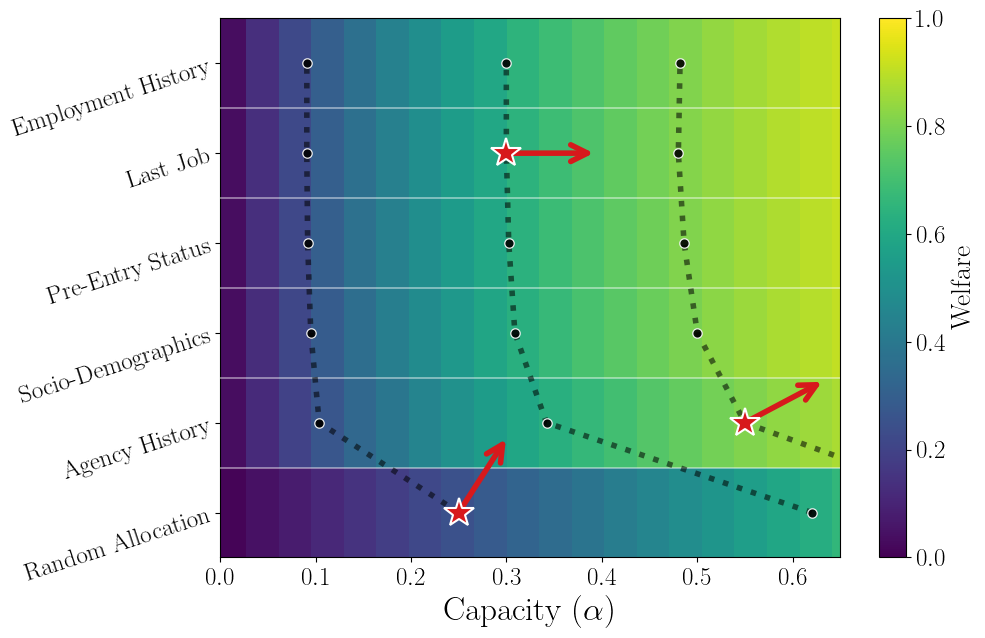

In [15]:
bucket_q1_status_quos = [
    {
        bucket_capacity_dim: 0.25,
        bucket_feature_dim: list(bucket_feature_dim.values)[0],
    },
    {
        bucket_capacity_dim: 0.55,
        bucket_feature_dim: list(bucket_feature_dim.values)[1],
    },
    {
        bucket_capacity_dim: 0.3,
        bucket_feature_dim: list(bucket_feature_dim.values)[-2],
    },
]

fig, ax = plot_welfare_surface(
    bucket_space,
    dim_x=bucket_capacity_dim,
    dim_y=bucket_feature_dim,
    welfare_metric="mean_utility",
    normalize_by=BETA,
    n=30,
    xlim=(0, 0.65),
    contour_labels=False,
    discrete_contour_guides=True,
    n_contours=0,
    status_quo=bucket_q1_status_quos,
    status_quo_gradient_label=True,
    status_quo_contour_clearance=0.75,
    cmap="viridis",
    cbar_label="Welfare",
)

format_bucket_surface_axis(ax, bucket_feature_dim.values)
plt.show()


## (Q2) Inspecting Optimality


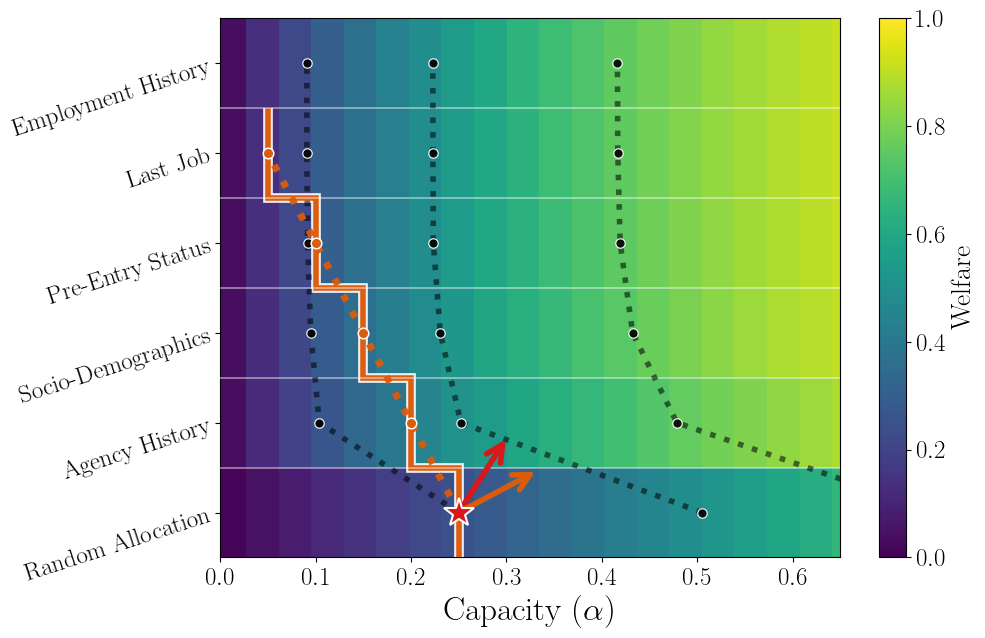

In [16]:
FEATURE_BUCKET_COST_AS_CAPACITY_SHARE = 0.05

employment_q2_status_quo = {
    bucket_capacity_dim: 0.25,
    bucket_feature_dim: list(bucket_feature_dim.values)[0],
}
q2_row = list(bucket_feature_dim.values).index(employment_q2_status_quo[bucket_feature_dim])
q2_alpha = float(employment_q2_status_quo[bucket_capacity_dim])

employment_bucket_cost_surface = CostSurface(
    lambda config: bucket_data_by_package["Pre-Entry Status"].n * (
        float(config[bucket_capacity_dim])
        + FEATURE_BUCKET_COST_AS_CAPACITY_SHARE
        * list(bucket_feature_dim.values).index(config[bucket_feature_dim])
    )
)

fig, ax = plot_welfare_surface(
    bucket_space,
    dim_x=bucket_capacity_dim,
    dim_y=bucket_feature_dim,
    welfare_metric="mean_utility",
    normalize_by=BETA,
    n=30,
    xlim=(0, 0.65),
    contour_labels=False,
    discrete_contour_guides=True,
    n_contours=3,
    status_quo=employment_q2_status_quo,
    cost_surface=employment_bucket_cost_surface,
    status_quo_gradient_label=False,
    cmap="viridis",
    cbar_label="Welfare",
)

format_bucket_surface_axis(ax, bucket_feature_dim.values)
plt.show()


## (Q3) Choosing Optimal Parameters


In [17]:
EMPLOYMENT_Q3_N_BUDGET_POINTS = 15
EMPLOYMENT_Q3_MAX_CAPACITY = 0.65
employment_q3_budgets = np.linspace(
    bucket_data_by_package["Pre-Entry Status"].n * bucket_capacity_dim.bounds[0],
    bucket_data_by_package["Pre-Entry Status"].n * (
        EMPLOYMENT_Q3_MAX_CAPACITY
        + FEATURE_BUCKET_COST_AS_CAPACITY_SHARE * (len(bucket_feature_dim.values) - 1)
    ),
    EMPLOYMENT_Q3_N_BUDGET_POINTS,
)

employment_q3_results, employment_q3_candidates = optimize_budget_frontier(
    space=bucket_space,
    cost_surface=employment_bucket_cost_surface,
    solve_dim=bucket_capacity_dim,
    budgets=employment_q3_budgets,
    dims=[bucket_capacity_dim, bucket_feature_dim],
    welfare_metric="mean_utility",
    return_candidates=True,
)


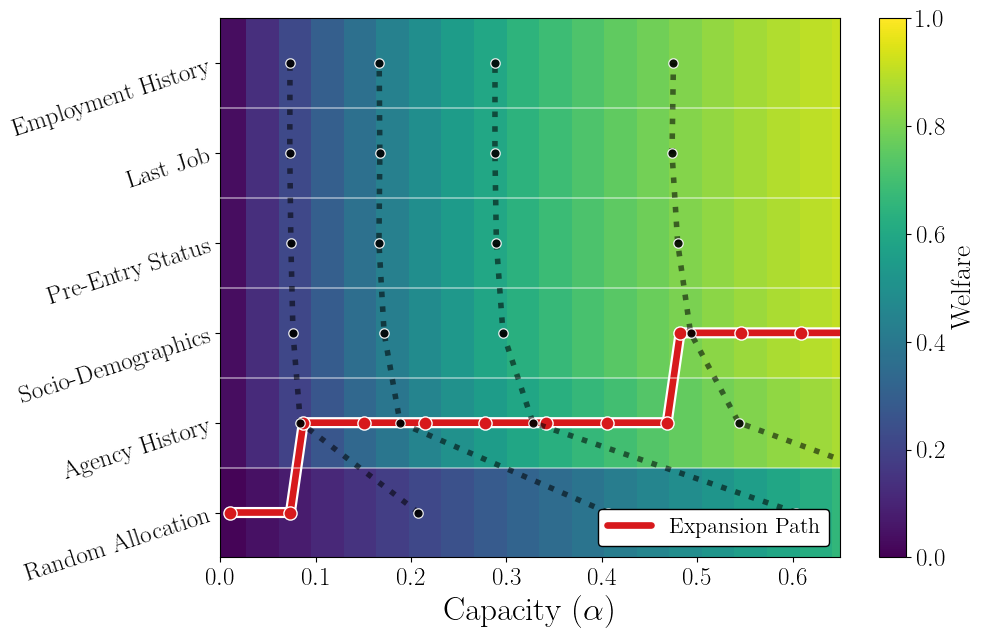

In [18]:
fig, ax = plot_welfare_surface(
    bucket_space,
    dim_x=bucket_capacity_dim,
    dim_y=bucket_feature_dim,
    welfare_metric="mean_utility",
    normalize_by=BETA,
    n=30,
    contour_labels=False,
    discrete_contour_guides=True,
    n_contours=4,
    xlim=(0, 0.65),
    path_results=employment_q3_results,
    path_label="Expansion Path",
    path_linewidth=4.8,
    path_underlay_linewidth=8.0,
    path_linestyle="-",
    path_marker_size=90,
    path_legend_loc="lower right",
    cmap="viridis",
    cbar_label="Welfare",
)

format_bucket_surface_axis(ax, bucket_feature_dim.values)
plt.show()
